In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
import zipfile
zip_path = r"C:\Users\Shree\Downloads\TwYntYAlAcoQRutU (1).zip"
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("heart_disease")

In [3]:
columns = [
       "age" ,      
       "sex",    
       "cp",   
        "trestbps", 
       "chol",     
       "fbs",      
       "restecg",   
        "thalach",   
       "exang",     
        "oldpeak",   
        "slope",     
        "ca",        
        "thal",
        "target"       
]
df = pd.read_csv("heart_disease/processed.cleveland.data", header = None, names=columns)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [5]:
df.shape

(303, 14)

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [8]:
# we have to check ca,and thal clocals because there dtype is object(2) data type does not match what it should logically be
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df = pd.read_csv("heart_disease/processed.cleveland.data", header = None, names=columns, na_values="?")
df.head()
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [12]:
clean_df = df.copy()
clean_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [13]:
clean_df = clean_df.dropna()  # i choose this method because percentage of null values Very small size: Less than 2% of data is very small.

In [14]:
clean_df.shape
clean_df.describe()
clean_df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

In [15]:
def replace_outliers(data, column, method="median"):
    #calculate Q1 ,Q3 , IQRabs
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR 
    upper = Q3 + 1.5*IQR

    # replace 
    if method =="median":
        replace_value = data[column].median()
    elif method =="mode":
        replace_value = data[column].mode()[0]
    else:
        raise ValueError("Method should be 'median' or 'mode'")

    outliers = data.loc[
         (data[column]<lower) | (data[column]>upper),
         column
    ].copy()

    # 
    if len(outliers)> 0:
        print(f"\nColumn: {column}")
        print(f"Replacement Method : {method}")
        print(f"Replacement Value: {replace_value}")
        print("Replaced Values:")

        for index, value in outliers.items():
            print (f"Row {index}:{value}--->{replace_value}")
    else:
        print(f"\nColumn:{column}")
        print("No Outliers Found.")

    # Replace Outliers 
    data [column] = np.where((data[column]<lower) |  (data[column]>upper),replace_value,data[column] )
    return data 
    

In [16]:
columns = [
        "age" , 
        "trestbps", 
        "chol",              
        "thalach",     
        "oldpeak"
]  
for col in columns:
    clean_df = replace_outliers (
    clean_df,
    col,
    method ="median"
   )


Column:age
No Outliers Found.

Column: trestbps
Replacement Method : median
Replacement Value: 130.0
Replaced Values:
Row 14:172.0--->130.0
Row 83:180.0--->130.0
Row 126:200.0--->130.0
Row 172:174.0--->130.0
Row 183:178.0--->130.0
Row 188:192.0--->130.0
Row 201:180.0--->130.0
Row 213:178.0--->130.0
Row 231:180.0--->130.0

Column: chol
Replacement Method : median
Replacement Value: 243.0
Replaced Values:
Row 48:417.0--->243.0
Row 121:407.0--->243.0
Row 152:564.0--->243.0
Row 173:394.0--->243.0
Row 181:409.0--->243.0

Column: thalach
Replacement Method : median
Replacement Value: 153.0
Replaced Values:
Row 245:71.0--->153.0

Column: oldpeak
Replacement Method : median
Replacement Value: 0.8
Replaced Values:
Row 91:6.2--->0.8
Row 123:5.6--->0.8
Row 183:4.2--->0.8
Row 191:4.2--->0.8
Row 285:4.4--->0.8


In [17]:
clean_df["target_binary"] = clean_df["target"].apply(
    lambda x: 0 if x==0 else 1
)

In [18]:
clean_df["target_binary"].value_counts()

target_binary
0    160
1    137
Name: count, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
x = clean_df.drop(
    ["target","target_binary"],axis=1
)
y = clean_df["target_binary"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
    
print("x_train :", x_train.shape)
print("x_test :", x_test.shape)
print("y_train :", y_train.shape)
print("y_train :", y_train.shape)

x_train : (237, 13)
x_test : (60, 13)
y_train : (237,)
y_train : (237,)


In [20]:
numeric_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]


one_hot_cols = [
    "cp",
    "restecg",
    "ca",
    "thal"
]


ordinal_cols = [
    "slope"
]


binary_cols = [
    "sex",
    "fbs",
    "exang"
]

# Create Column Transformer

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
      StandardScaler,
       OneHotEncoder,
      OrdinalEncoder
)

In [22]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_cols
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            one_hot_cols
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[[1,2,3]]
            ),
            ordinal_cols
        ),

        (
            "binary",
            "passthrough",
            binary_cols
        )

    ]

)

# Baseline Models Train

In [23]:
x_train_processed  = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)
print(x_test_processed.shape)
print(x_train_processed.shape)

(60, 23)
(237, 23)


# Comparative Analysis of Classification Models

In [24]:
!pip install xgboost

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [26]:
from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
classification_report
)

In [27]:
models = {
    "Logistic Regression":
    LogisticRegression(max_iter=1000,
                      random_state=42
                      ),
    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
        ),
    "Rnadom Forest":
    RandomForestClassifier(
        random_state=42
    ),
    "XGBoost":
    XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.06,
        max_depth=3,
        eval_metric= "logloss"
    )
}

In [28]:
results = []
for name, model in models.items():
    model.fit(x_train_processed, y_train)
    
    y_pred = model.predict (x_test_processed)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred), 
        "F1 Score": f1_score(y_test, y_pred)
    })

In [29]:
# now we try to print all model result and compare them all model in one place 

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Rnadom Forest,0.833333,0.846154,0.785714,0.814815
3,XGBoost,0.816667,0.840000,0.750000,0.792453
0,Logistic Regression,0.766667,0.791667,0.678571,0.730769
1,Decision Tree,0.716667,0.703704,0.678571,0.690909


* **Random Forest** achieved the best overall performance among all the evaluated models.
* It recorded the highest **Accuracy (83.33%)**, **Precision (84.62%)**, **Recall (78.57%)**, and **F1 Score (81.48%)**.
* **Logistic Regression** ranked second in terms of overall performance.
* **XGBoost** showed moderate performance but was less effective than Random Forest and Logistic Regression.
* **Decision Tree** achieved the lowest performance among the evaluated models based on the selected metrics.


# Create Pipeline 

In [30]:
from sklearn.pipeline import Pipeline
#from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model",RandomForestClassifier( random_state=42)
        )
    ]
)

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


cv_scores = cross_val_score(
    rf_pipe,
    x,
    y,
    cv=cv,
    scoring="f1"
)


print("Fold Scores:", cv_scores)

print("Mean F1:", cv_scores.mean())

print("Std:", cv_scores.std())

Fold Scores: [0.86206897 0.82758621 0.71698113 0.78431373 0.80851064]
Mean F1: 0.7998921336554666
Std: 0.04862945551676032


# Hyperparameter Search 

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
param_grid = {

    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        3,
        5,
        7,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ]

}

In [34]:
rf_grid = GridSearchCV(

    estimator=rf_pipe,

    param_grid=param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1

)

In [35]:
rf_grid.fit(x,y)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('onehot', ...), ...]"


In [36]:
print (rf_grid.best_params_)

{'model__max_depth': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [37]:
print( rf_grid.best_score_)

0.816478182136807


In [38]:
{
    'model__max_depth': 3,
    'model__min_samples_split': 5,
    'model__n_estimators': 100
}

{'model__max_depth': 3,
 'model__min_samples_split': 5,
 'model__n_estimators': 100}

# Overfitting Check

In [39]:
best_model = rf_grid.best_estimator_

In [40]:
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

In [41]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
def evaluate_model(y_true, y_pred, dataset_name):
    print(dataset_name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:",precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    
    print("------------------------------")

In [42]:
evaluate_model(
    y_train,y_train_pred,"Training Data"
)

evaluate_model(
    y_test,y_test_pred,"Testing Data"
)

Training Data
Accuracy: 0.8734177215189873
Precision: 0.8910891089108911
Recall: 0.8256880733944955
F1 Score: 0.8571428571428571
------------------------------
Testing Data
Accuracy: 0.85
Precision: 0.9130434782608695
Recall: 0.75
F1 Score: 0.8235294117647058
------------------------------


* The model achieved strong performance on the **training data** with an accuracy of **87.34%** and an F1 Score of **85.71%**, indicating good learning ability and balanced classification performance.
* On the **testing data**, the model maintained good generalization with **85% accuracy** and **91.30% precision**, showing reliable prediction performance on unseen data.


# Confusion Matrix

In [43]:
from sklearn.metrics import confusion_matrix

cm= confusion_matrix(
    y_test,y_test_pred
)
cm

array([[30,  2],
       [ 7, 21]])

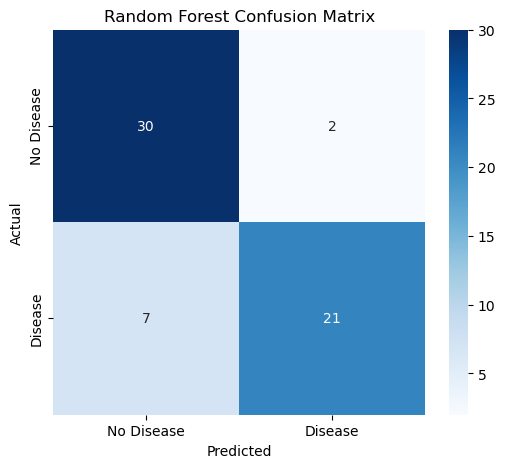

In [44]:


plt.figure(figsize=(6,5))
sns.heatmap(
    cm,annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=["No Disease","Disease"],
    yticklabels =["No Disease","Disease"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Class Imbalance


In [45]:
clean_df["target_binary"].value_counts(normalize=True)

target_binary
0    0.538721
1    0.461279
Name: proportion, dtype: float64

 Class Imbalance

The target class distribution was checked before model training.

Class 0 (No Heart Disease): 53.87%

Class 1 (Heart Disease): 46.13%

Since the minority class represents more than 35% of the dataset,
the classes are considered sufficiently balanced. Therefore, no rebalancing
technique (SMOTE, Oversampling, or Undersampling) was applied.

# Save Final Model 

In [46]:
import joblib

In [47]:
best_model = rf_grid.best_estimator_

joblib.dump(best_model,"Heart_Disease_Model.pkl")

['Heart_Disease_Model.pkl']

In [48]:
loaded_model = joblib.load("Heart_Disease_Model.pkl")
print(type(loaded_model ))


<class 'sklearn.pipeline.Pipeline'>


In [49]:
y_pred_loaded = loaded_model.predict(x_test)
print(y_pred_loaded[:10])

[0 0 0 0 0 0 1 0 0 0]


In [50]:
from sklearn.metrics import accuracy_score

y_pred_loaded = loaded_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_loaded))

Accuracy: 0.85


In [51]:
# # Empty text file तयार करा
# with open("requirements.txt", "w") as f:
#     pass

# print("Empty requirements.txt file created successfully!")

In [52]:
# # Create an empty README.md file
# with open("README.md", "w", encoding="utf-8") as f:
#     pass

# print("README.md created successfully!")